# Machine Learning for Regression

In [1]:
import pandas as pd
import numpy as np

## 2.2 Data preparation 

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-05-19 15:52:46--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.12’

data.csv.12         100%[===================>]   1.41M  --.-KB/s    in 0.007s  

2026-05-19 15:52:46 (212 MB/s) - ‘data.csv.12’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv.3')

In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
string = list(df.dtypes[df.dtypes == 'str'].index)
string

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in string:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [10]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## 2.3 Exploratory data analysis

In [12]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

## Distribution of prices


In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

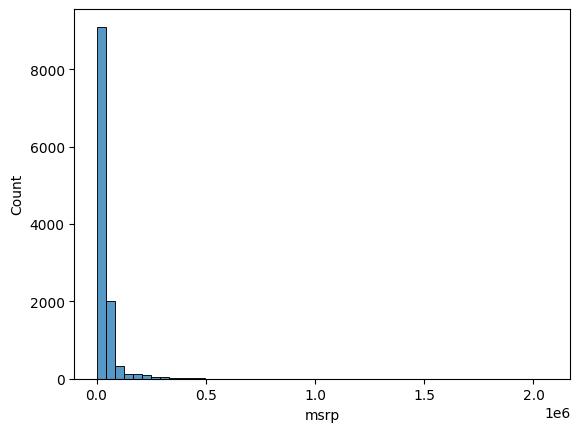

In [14]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

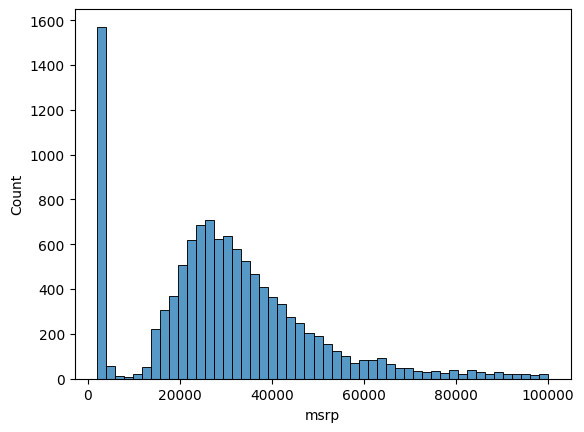

In [15]:
sns.histplot(df.msrp[df.msrp<100000], bins=50)

In [16]:
np.log([1, 10, 1000, 10000])

array([0.        , 2.30258509, 6.90775528, 9.21034037])

<Axes: xlabel='msrp', ylabel='Count'>

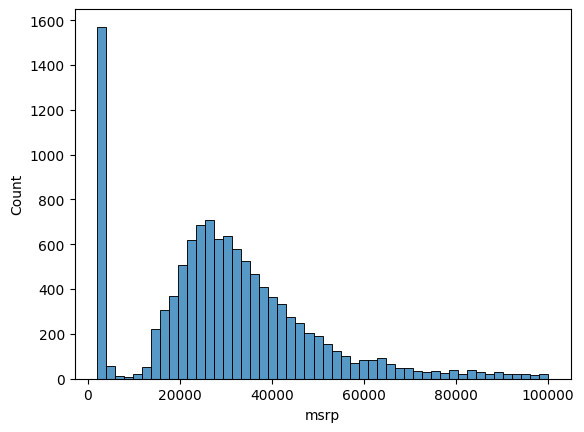

In [17]:
sns.histplot(df.msrp[df.msrp<100000], bins=50)

Standardizing the distribution of prices

In [18]:
price_logs = np.log1p(df.msrp)

In [19]:
price_logs.describe()

count    11914.000000
mean        10.113729
std          1.105703
min          7.601402
25%          9.952325
50%         10.308819
75%         10.650939
max         14.541078
Name: msrp, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

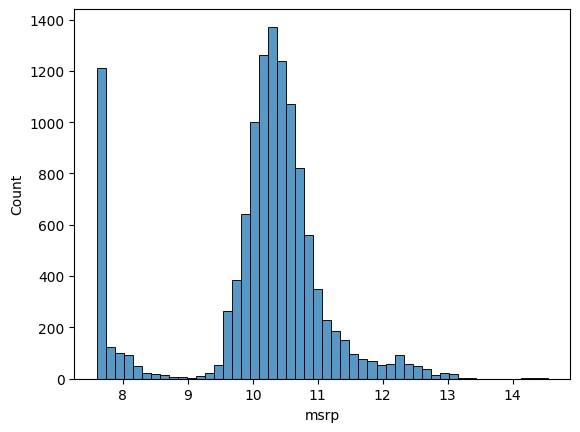

In [20]:
sns.histplot(price_logs, bins=50)

No more tail. Price Distribution looks similar to normal distribution now.

### Missing values

In [21]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 Setting up the validation framework

In [22]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [23]:
n, n_train,n_val, n_test

(11914, 7150, 2382, 2382)

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df.drop(columns= 'msrp')
y = price_logs

In [26]:
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size= 0.4 , random_state = 2)

In [27]:
X_val, X_test, y_val , y_test = train_test_split( X_test, y_test, test_size= 0.5 , random_state = 2)

## 2.5 Linear Regression

In [28]:
X_train=X_train.reset_index(drop = True)

In [29]:
X_train.iloc[10]

make                          chevrolet
model                   c/k_1500_series
year                               1997
engine_fuel_type       regular_unleaded
engine_hp                         200.0
engine_cylinders                    6.0
transmission_type                manual
driven_wheels          rear_wheel_drive
number_of_doors                     2.0
market_category                     NaN
vehicle_size                      large
vehicle_style        regular_cab_pickup
highway_mpg                          20
city_mpg                             15
popularity                         1385
Name: 10, dtype: object

In [30]:
X_test=X_test.reset_index(drop = True)

In [31]:
y_train=y_train.reset_index(drop = True)
y_train

0        9.798183
1        9.679781
2       10.682491
3       10.188328
4        7.646831
          ...    
7143     7.627057
7144    10.165698
7145    10.278528
7146    10.007893
7147    10.404142
Name: msrp, Length: 7148, dtype: float64

In [32]:
X_val=X_val.reset_index(drop = True)

In [33]:
y_test=y_test.reset_index(drop = True)

In [34]:
y_val=y_val.reset_index(drop = True)

In [35]:
# Example using one vector
xi = [453, 11, 86]

In [36]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [37]:
def linea_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]
        
    return pred

In [38]:
linea_regression(xi) # returns logarithmic value

12.312

In [39]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [40]:
np.log1p(222347.2221101062)

np.float64(12.312)

### Linear reg: vector form
an example generalizing the linear regression formula

In [41]:
def dot(xi,w):
    n = len(xi)

    res = 0.0

    for j in range(n):
       res = res + w[j] * xi[j]
        
    return res

In [42]:
w_new =[w0] + w
w_new 

[7.17, 0.01, 0.04, 0.002]

In [43]:
def linea_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [44]:
linea_regression(xi)

12.312

In [45]:
# Application on all training examples
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [46]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

In [47]:
X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [48]:
def linear_regression(X) :
    return X.dot(w_new)

In [49]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

## 2.7 Training linear regression model
i.e getting the weights

In [50]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [51]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [52]:
X = np.column_stack([ones, X])
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [53]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [54]:
XTX = X.T.dot(X)

In [55]:
XTX_inv = np.linalg.inv(XTX)

In [56]:
w_full = XTX_inv.dot(X.T).dot(y)

In [57]:
w_full

array([ 3.00067767e+02, -2.27742529e-01, -2.57694130e+00, -2.30120640e-02])

In [58]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [59]:
def train_lin_reg(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [60]:
train_lin_reg(X, y)

(np.float64(300.06776692555627),
 array([-0.22774253, -2.5769413 , -0.02301206]))

## 2.8 Car price baseline model

In [61]:
X_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [62]:
X_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [63]:
base = ['engine_hp',
       'engine_cylinders',
        'highway_mpg', 
        'city_mpg', 
        'popularity']

In [64]:
X_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,132.0,4.0,35,27,1439
1,101.0,4.0,33,27,819
2,302.0,8.0,16,11,61
3,207.0,6.0,17,14,586
4,230.0,8.0,15,12,1851
...,...,...,...,...,...
7143,200.0,6.0,18,13,1385
7144,160.0,4.0,33,29,640
7145,250.0,6.0,22,15,1851
7146,174.0,4.0,42,31,2202


In [65]:
y_train = y_train.values

In [66]:
X_train = X_train[base].fillna(0).values

In [67]:
w0, w = train_lin_reg(X_train, y_train)

In [68]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

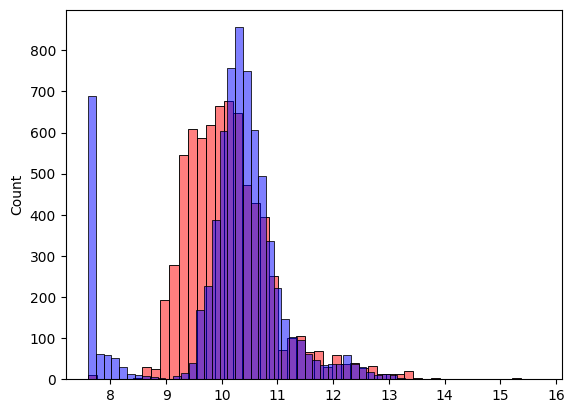

In [72]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
